# Project - Salary prediction 


In [2]:
# Step 1 - Import Required libraries
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import joblib
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline


# Step 2 - Load Dataset

In [184]:
df = pd.read_csv(r"\Users\navne\Downloads\Salary_Data (1).csv")
df.head()

,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891


# Step 3- Explore Set

In [185]:
# Check the null Value
df.isnull().sum()

YearsExperience    0
Salary             0
dtype: int64

In [186]:
df.columns

Index(['YearsExperience', 'Salary'], dtype='object')

In [187]:
# Describing 
df.describe()

,YearsExperience,Salary
count,30.000000,30.000000
mean,5.313333,76003.000000
std,2.837888,27414.429785
min,1.100000,37731.000000
25%,3.200000,56720.750000
50%,4.700000,65237.000000
75%,7.700000,100544.750000
max,10.500000,122391.000000


# Step 4 - Visualize in Relationship

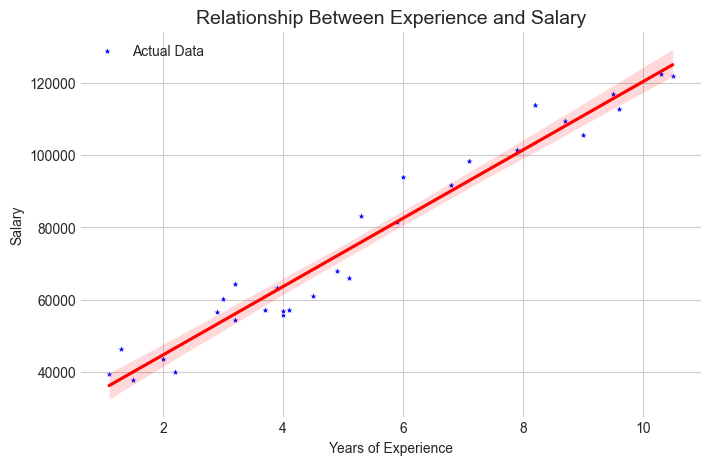

In [188]:
# Graphical Represention
plt.figure(figsize=(8,5))
sns.set_style("whitegrid")
sns.scatterplot(data=df, x="YearsExperience", y="Salary", color="blue", marker="*", label="Actual Data")
sns.regplot(data=df, x="YearsExperience", y="Salary", scatter=False, color="red", label="Regression Line")
plt.title("Relationship Between Experience and Salary", fontsize=14)
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.show()


# Step 5 - Split Data

In [189]:
x = df[["YearsExperience"]] # independent Variable
y = df["Salary"] # Dependent Variable

# Step 6 - Train Model

In [190]:
# split to be data
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state = 42)

# call the model
lr = LinearRegression()

# fit Data
lr.fit(x_train,y_train)

# score of Data
score = lr.score(x_test,y_test)
print("Model Accuracy (R²):", score)

Model Accuracy (R²): 0.9024461774180497


# step 8 - Model Evaluation metrics


In [191]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nModel Evaluation Metrics:")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R² Score: {r2:.2f}")


Model Evaluation Metrics:
Mean Absolute Error (MAE): 6286.45
Mean Squared Error (MSE): 49830096.86
R² Score: 0.90


# Step 9 -  Visualization Predication vs Actual Data graph

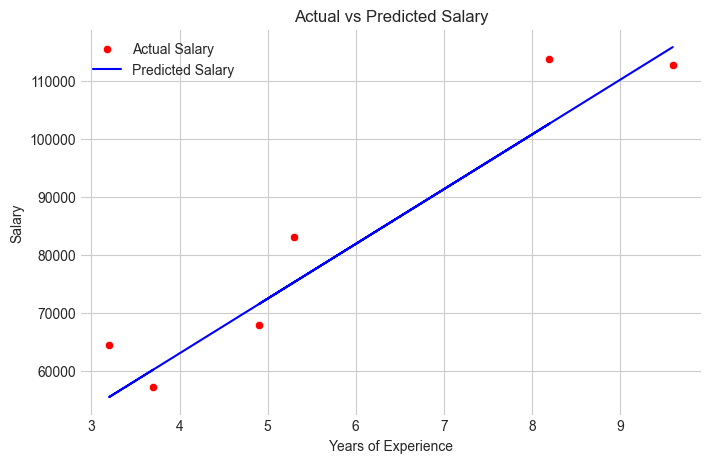

In [192]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=x_test.values.flatten(), y=y_test, color='red', label='Actual Salary')
plt.plot(x_test.values.flatten(), y_pred, color='blue', label='Predicted Salary')
plt.title("Actual vs Predicted Salary")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.legend()
plt.show()


# Step 10 - Save Model in Joblib

In [193]:
joblib.dump(lr,"linear_regression_salary_model.pkl")
print("\n Model Save Sucessfully as linear_regression_salary_model.pkl")


 Model Save Sucessfully as linear_regression_salary_model.pkl


# Step 11 - Load and Save Test model

In [194]:
loaded_model = joblib.load("linear_regression_salary_model.pkl")

# Step 12 - Predict the new Value Salary


In [195]:
exp = float(input("Enter the experience of years : "))
pred_salary = loaded_model.predict([[exp]])
print(f"Predicted Salary of {exp} years is experience : ${pred_salary[0]:2f}")

Enter the experience of years :  5


Predicted Salary of 5.0 years is experience : $72440.659627
